# Paper graph-signal benchmarks
Compare exclusive-lineage GIN, ring-fraction MLP and ring-size controls on identical saved validation folds. Training-time signal controls are separated from inference-only shuffles of intact-trained GINs. Every validation cell is evaluated; MSE and MAE are reduced within organoids before averaging organoids, with SEM bands. Crypt/neck/villus use the legacy normalized-distance categories. This notebook performs no training and retains only one restored checkpoint and small ego batches in memory. Figure tables and exports belong to the dedicated paper study.

In [1]:
from pathlib import Path
import sys
import json
import hashlib
import gc
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from functools import lru_cache
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/models/gnn.py').is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0,str(PROJECT_ROOT))
from src.artifacts.runs import AnalysisRun
from src.artifacts.provenance import workflow_fingerprint
from src.analysis.metrics.evaluation import prediction_table, organoid_mse_summary
from src.analysis.spatial.regions import signed_neck_regions
from src.data.subgraphs import build_ego_subgraphs_for_graph
from src.data.permutation import permute_ego_neighborhood_within_rings
from src.analysis.interventions.perturbation import predict_subgraph_center_distribution


## Settings
Select the saved study and configure inference resources and reproducible permutations.

In [2]:
# Study and inference
STUDY_DIR = PROJECT_ROOT/'paper_results/exclusive_lineages/paper_exclusive_20261006_153255'  # Dedicated paper output.
MANIFEST = json.loads((STUDY_DIR/'manifest.json').read_text())  # Exact saved runs.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # Inference device.
BATCH_SIZE = 64  # Maximum graphs per inference batch.
RECOMPUTE = False  # Reuse caches from identical code/settings.

# Reporting and anatomical definitions
CURVATURE_SCALE = 1e-4  # Gaussian curvature and MAE to um^-2; MSE uses square.
CRYPT_MAX = .75  # Legacy normalized crypt-distance threshold.
NECK_MAX = 1.1  # Legacy neck upper boundary, inclusive.
FIGURE_FORMATS = ['png','pdf']  # Figure exports.

# Inference-only permutations
PERMUTATION_SEED = 42  # Shared across checkpoints and depths.
PERMUTATION_REPEATS = 1  # Average errors over independent shuffles.
EGO_RADIUS = 4  # Common context, sufficient for every depth 0–4.


## Restore runs and define reductions
Reduce cell errors to matched organoid/region summaries immediately; cache by executable-code fingerprint.

In [3]:
def save_figure(fig, path):
    path.parent.mkdir(parents=True,exist_ok=True)
    for extension in FIGURE_FORMATS:
        fig.savefig(path.with_suffix('.'+extension),dpi=180,bbox_inches='tight')
    plt.show()
    plt.close(fig)

METRIC_LABELS = {'mse':r'MSE ($\mu$m$^{-4}$)', 'mae':r'MAE ($\mu$m$^{-2}$)'}
run = AnalysisRun(MANIFEST['runs']['controls'])
assert (run.directory/'complete.json').exists()
OUTPUT_DIR = STUDY_DIR/'graph_controls'
OUTPUT_DIR.mkdir(exist_ok=True)
CACHE = run.directory/'analysis'/'paper_graph_signals'/workflow_fingerprint(PROJECT_ROOT/'experiments/paper/graph_signal_benchmarks.ipynb')[:12]
CACHE.mkdir(parents=True,exist_ok=True)
DATA_DIR = PROJECT_ROOT/'training_data'/run.settings['dataset']
print(f'{len(run.records)} checkpoints; one model and bounded ego batches at a time.')

@lru_cache(maxsize=2000)
def annotation(oid):
    return signed_neck_regions(raw_graphs[oid],DATA_DIR,crypt_max=CRYPT_MAX,neck_max=NECK_MAX)

def reduce_errors(frame, record, condition):
    rows=[]
    for oid,f in frame.groupby('organoid_str',sort=False):
        labels=annotation(oid).set_index('node').loc[f.node,'region'].to_numpy()
        for region in ['total','crypt','neck','villus']:
            mask=np.ones(len(f),bool) if region=='total' else labels==region
            if not mask.any():continue
            g=f.iloc[np.flatnonzero(mask)]
            rows.append(dict(key=record['key'],name=record['name'],depth=record['depth'],fold=record['fold'],seed=record['seed'],
                training_signal=record['signal'],condition=condition,organoid_str=oid,region=region,n_cells=len(g),
                mse=float(g.squared_error.mean())*CURVATURE_SCALE**2,
                mae=float(g.absolute_error.mean())*CURVATURE_SCALE,
                baseline_mse=float(g.baseline_squared_error.mean())*CURVATURE_SCALE**2,
                baseline_mae=float(g.baseline_absolute_error.mean())*CURVATURE_SCALE))
    return pd.DataFrame(rows)


150 checkpoints; one model and bounded ego batches at a time.


## Evaluate trained controls
Each checkpoint uses its saved validation inputs, including its original training-signal transformation.

In [4]:
trained=[]
for i,record in enumerate(run.records.sort_values(['fold','depth','name','signal']).to_dict('records')):
    path=CACHE/f"trained_{record['key']}.csv"
    if RECOMPUTE or not path.exists():
        selection=run.select(record['key'],device=DEVICE)
        raw_graphs=selection['raw_graphs']
        frame=prediction_table(selection,device=DEVICE,batch_size=BATCH_SIZE)
        reduce_errors(frame,record,record['signal']).to_csv(path,index=False)
        del selection,frame
        run._data_cache.clear();gc.collect();torch.cuda.empty_cache()
    trained.append(pd.read_csv(path))
    print(f"Retrained controls {i+1}/{len(run.records)}: {record['key']}",flush=True)
trained=pd.concat(trained,ignore_index=True)
trained.to_csv(OUTPUT_DIR/'trained_control_errors.csv',index=False)


Retrained controls 1/150: gin_all_intact_d0_h128_f0_s42


Retrained controls 2/150: gin_all_permuted_d0_h128_f0_s42


Retrained controls 3/150: ring_all_intact_d0_h128_f0_s42


Retrained controls 4/150: ring_all_permuted_d0_h128_f0_s42


Retrained controls 5/150: ring-size_all_intact_d0_h128_f0_s42


...

Retrained controls 146/150: gin_all_permuted_d4_h128_f4_s42


Retrained controls 147/150: ring_all_intact_d4_h128_f4_s42


Retrained controls 148/150: ring_all_permuted_d4_h128_f4_s42


Retrained controls 149/150: ring-size_all_intact_d4_h128_f4_s42


Retrained controls 150/150: ring-size_all_permuted_d4_h128_f4_s42


## Trained-control figures
Each signal has its own panel. Ring-size receives center fate and counts only; ring receives ring fate fractions.

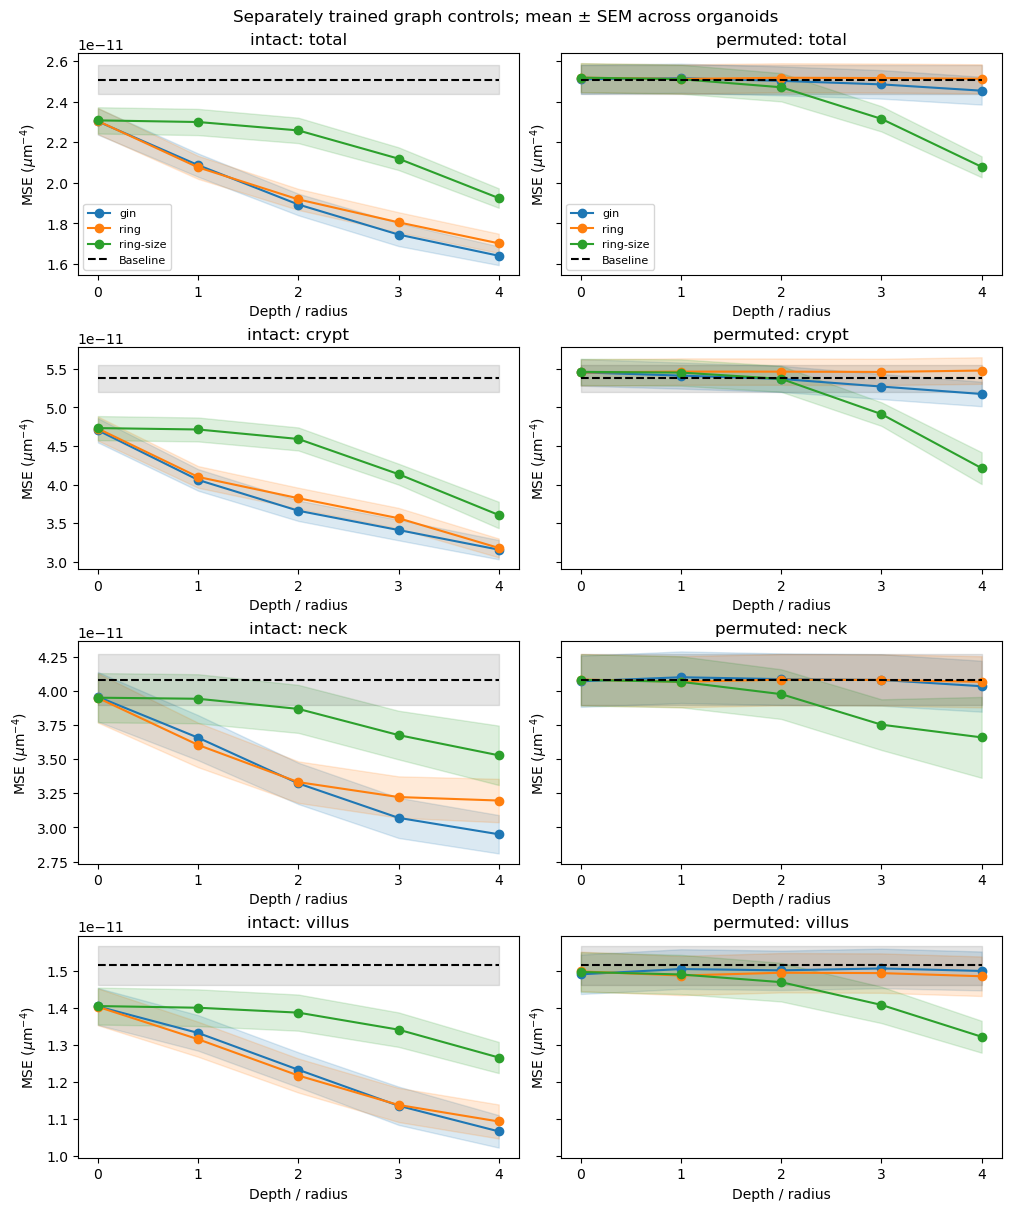

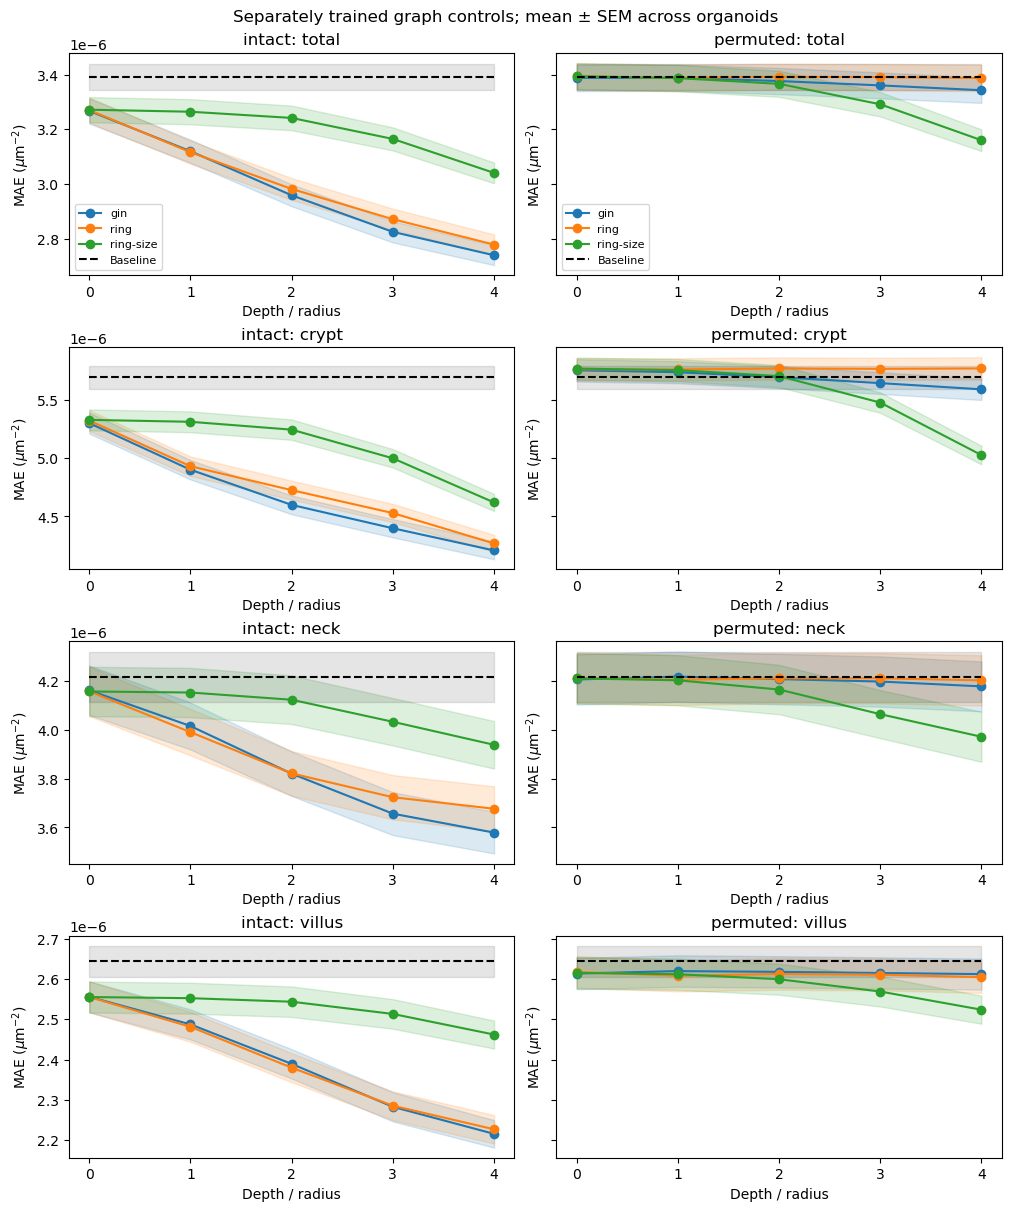

In [5]:
def depth_panels(table, *, family_column, panel_column, title, path):
    regions=['total','crypt','neck','villus']
    signals=table[panel_column].drop_duplicates().tolist()
    for metric in ['mse','mae']:
        fig,axes=plt.subplots(len(regions),len(signals),figsize=(5*len(signals),12),squeeze=False,sharey='row',layout='constrained')
        for ri,region in enumerate(regions):
            for ci,signal in enumerate(signals):
                ax=axes[ri,ci];f=table[(table.region==region)&(table[panel_column]==signal)]
                for label,g in f.groupby(family_column,sort=False):
                    curve=organoid_mse_summary(g,'depth',value=metric).sort_values('depth')
                    line,=ax.plot(curve.depth,curve['mean'],'o-',label=label)
                    ax.fill_between(curve.depth,curve['mean']-curve['sem'],curve['mean']+curve['sem'],color=line.get_color(),alpha=.16)
                b=f.drop_duplicates(['organoid_str','depth'])
                curve=organoid_mse_summary(b,'depth',value='baseline_'+metric).sort_values('depth')
                ax.plot(curve.depth,curve['mean'],'k--',label='Baseline')
                ax.fill_between(curve.depth,curve['mean']-curve['sem'],curve['mean']+curve['sem'],color='k',alpha=.10)
                ax.set(title=f'{signal}: {region}',xlabel='Depth / radius',ylabel=METRIC_LABELS[metric],xticks=range(5))
                if ri==0:ax.legend(fontsize=8)
        fig.suptitle(title+'; mean ± SEM across organoids')
        save_figure(fig,path.with_name(path.name+'_'+metric))

depth_panels(trained,family_column='name',panel_column='training_signal',title='Separately trained graph controls',path=OUTPUT_DIR/'trained_controls')


## Test intact-trained GINs under signal permutations
Whole-organoid shuffles include the center; ring shuffles preserve its identity and each exact ring composition. Intact ego predictions must reproduce full-graph predictions before interpreting changes.

In [6]:
def shuffled_errors(selection, record):
    full=prediction_table(selection,device=DEVICE,batch_size=BATCH_SIZE)
    parts=[reduce_errors(full,record,'intact')]
    checks=[]
    for graph in selection['groups']['val']:
        graph=graph.cpu();oid=str(graph.organoid_str)
        original=full[full.organoid_str==oid].sort_values('node').reset_index(drop=True)
        org_seed=int.from_bytes(hashlib.sha256(oid.encode()).digest()[:8],'little')
        per_repeat={'whole_organoid_permuted':[],'ring_permuted':[]}
        for repeat in range(PERMUTATION_REPEATS):
            seed=int(np.random.SeedSequence([PERMUTATION_SEED,org_seed,repeat]).generate_state(1)[0])
            generator=torch.Generator().manual_seed(seed)
            edited=copy.copy(graph)
            edited.x=graph.x[torch.randperm(len(graph.x),generator=generator)].clone()
            one=dict(selection);one['groups']={'val':[edited]}
            whole=prediction_table(one,device=DEVICE,batch_size=BATCH_SIZE)
            per_repeat['whole_organoid_permuted'].append(whole.sort_values('node').reset_index(drop=True))
            chunks=[];max_difference=0.
            for start in range(0,len(graph.x),BATCH_SIZE):
                centers=list(range(start,min(start+BATCH_SIZE,len(graph.x))))
                subs=build_ego_subgraphs_for_graph(graph,num_hops=EGO_RADIUS,centers=centers)
                intact,lv=predict_subgraph_center_distribution(subs,selection['model'],device=DEVICE,batch_size=BATCH_SIZE)
                expected=original.loc[centers,'pred_transformed'].to_numpy()
                np.testing.assert_allclose(intact,expected,rtol=2e-4,atol=2e-6)
                max_difference=max(max_difference,float(np.max(abs(intact-expected))))
                shuffled=permute_ego_neighborhood_within_rings(subs,EGO_RADIUS,inplace=False,generator=generator)
                mu,lv=predict_subgraph_center_distribution(shuffled,selection['model'],device=DEVICE,batch_size=BATCH_SIZE)
                _,physical,_=selection['transform'].inverse_distribution(None,mu,lv,graphs=subs,center_only=True)
                pred=np.asarray(physical).reshape(-1)+np.asarray(selection['baseline_offsets'][oid]).reshape(-1)[centers]
                f=original.loc[centers].copy();error=pred-f.y_true.to_numpy()
                f['squared_error']=error**2;f['absolute_error']=abs(error)
                chunks.append(f)
            per_repeat['ring_permuted'].append(pd.concat(chunks,ignore_index=True))
            checks.append(dict(key=record['key'],organoid_str=oid,repeat=repeat,max_abs_intact_difference=max_difference))
        for condition,frames in per_repeat.items():
            averaged=frames[0].copy()
            for metric in ['squared_error','absolute_error']:
                averaged[metric]=np.mean([f[metric].to_numpy() for f in frames],axis=0)
            parts.append(reduce_errors(averaged,record,condition))
    return pd.concat(parts,ignore_index=True),pd.DataFrame(checks)

intact_records=run.records[(run.records.name=='gin')&(run.records.signal=='intact')].sort_values(['fold','depth'])
permutations=[];all_checks=[]
for i,record in enumerate(intact_records.to_dict('records')):
    path=CACHE/f"inference_{record['key']}.csv"
    checkpath=CACHE/f"checks_{record['key']}.csv"
    if RECOMPUTE or not path.exists():
        selection=run.select(record['key'],device=DEVICE);raw_graphs=selection['raw_graphs']
        scores,checks=shuffled_errors(selection,record)
        checks.to_csv(checkpath,index=False);scores.to_csv(path,index=False)
        del selection,scores,checks
        run._data_cache.clear();gc.collect();torch.cuda.empty_cache()
    permutations.append(pd.read_csv(path));all_checks.append(pd.read_csv(checkpath))
    print(f"Inference permutations {i+1}/{len(intact_records)}: {record['key']}",flush=True)
permutations=pd.concat(permutations,ignore_index=True)
permutations.to_csv(OUTPUT_DIR/'intact_gin_permutation_errors.csv',index=False)
pd.concat(all_checks).to_csv(CACHE/'intact_ego_checks.csv',index=False)
zero=permutations[permutations.depth==0].pivot(index=['organoid_str','region'],columns='condition',values='mse')
np.testing.assert_allclose(zero.intact,zero.ring_permuted,rtol=1e-4,atol=1e-15)

Inference permutations 1/25: gin_all_intact_d0_h128_f0_s42


Inference permutations 2/25: gin_all_intact_d1_h128_f0_s42


Inference permutations 3/25: gin_all_intact_d2_h128_f0_s42


Inference permutations 4/25: gin_all_intact_d3_h128_f0_s42


Inference permutations 5/25: gin_all_intact_d4_h128_f0_s42


...

Inference permutations 21/25: gin_all_intact_d0_h128_f4_s42


Inference permutations 22/25: gin_all_intact_d1_h128_f4_s42


Inference permutations 23/25: gin_all_intact_d2_h128_f4_s42


Inference permutations 24/25: gin_all_intact_d3_h128_f4_s42


Inference permutations 25/25: gin_all_intact_d4_h128_f4_s42


## Intact versus ring-permuted evaluation
Compare the same intact-trained GIN on intact and ring-permuted validation inputs. Each panel shows both curves against depth for one region; shaded bands show the SEM across organoids. The two figures report MSE and MAE separately.

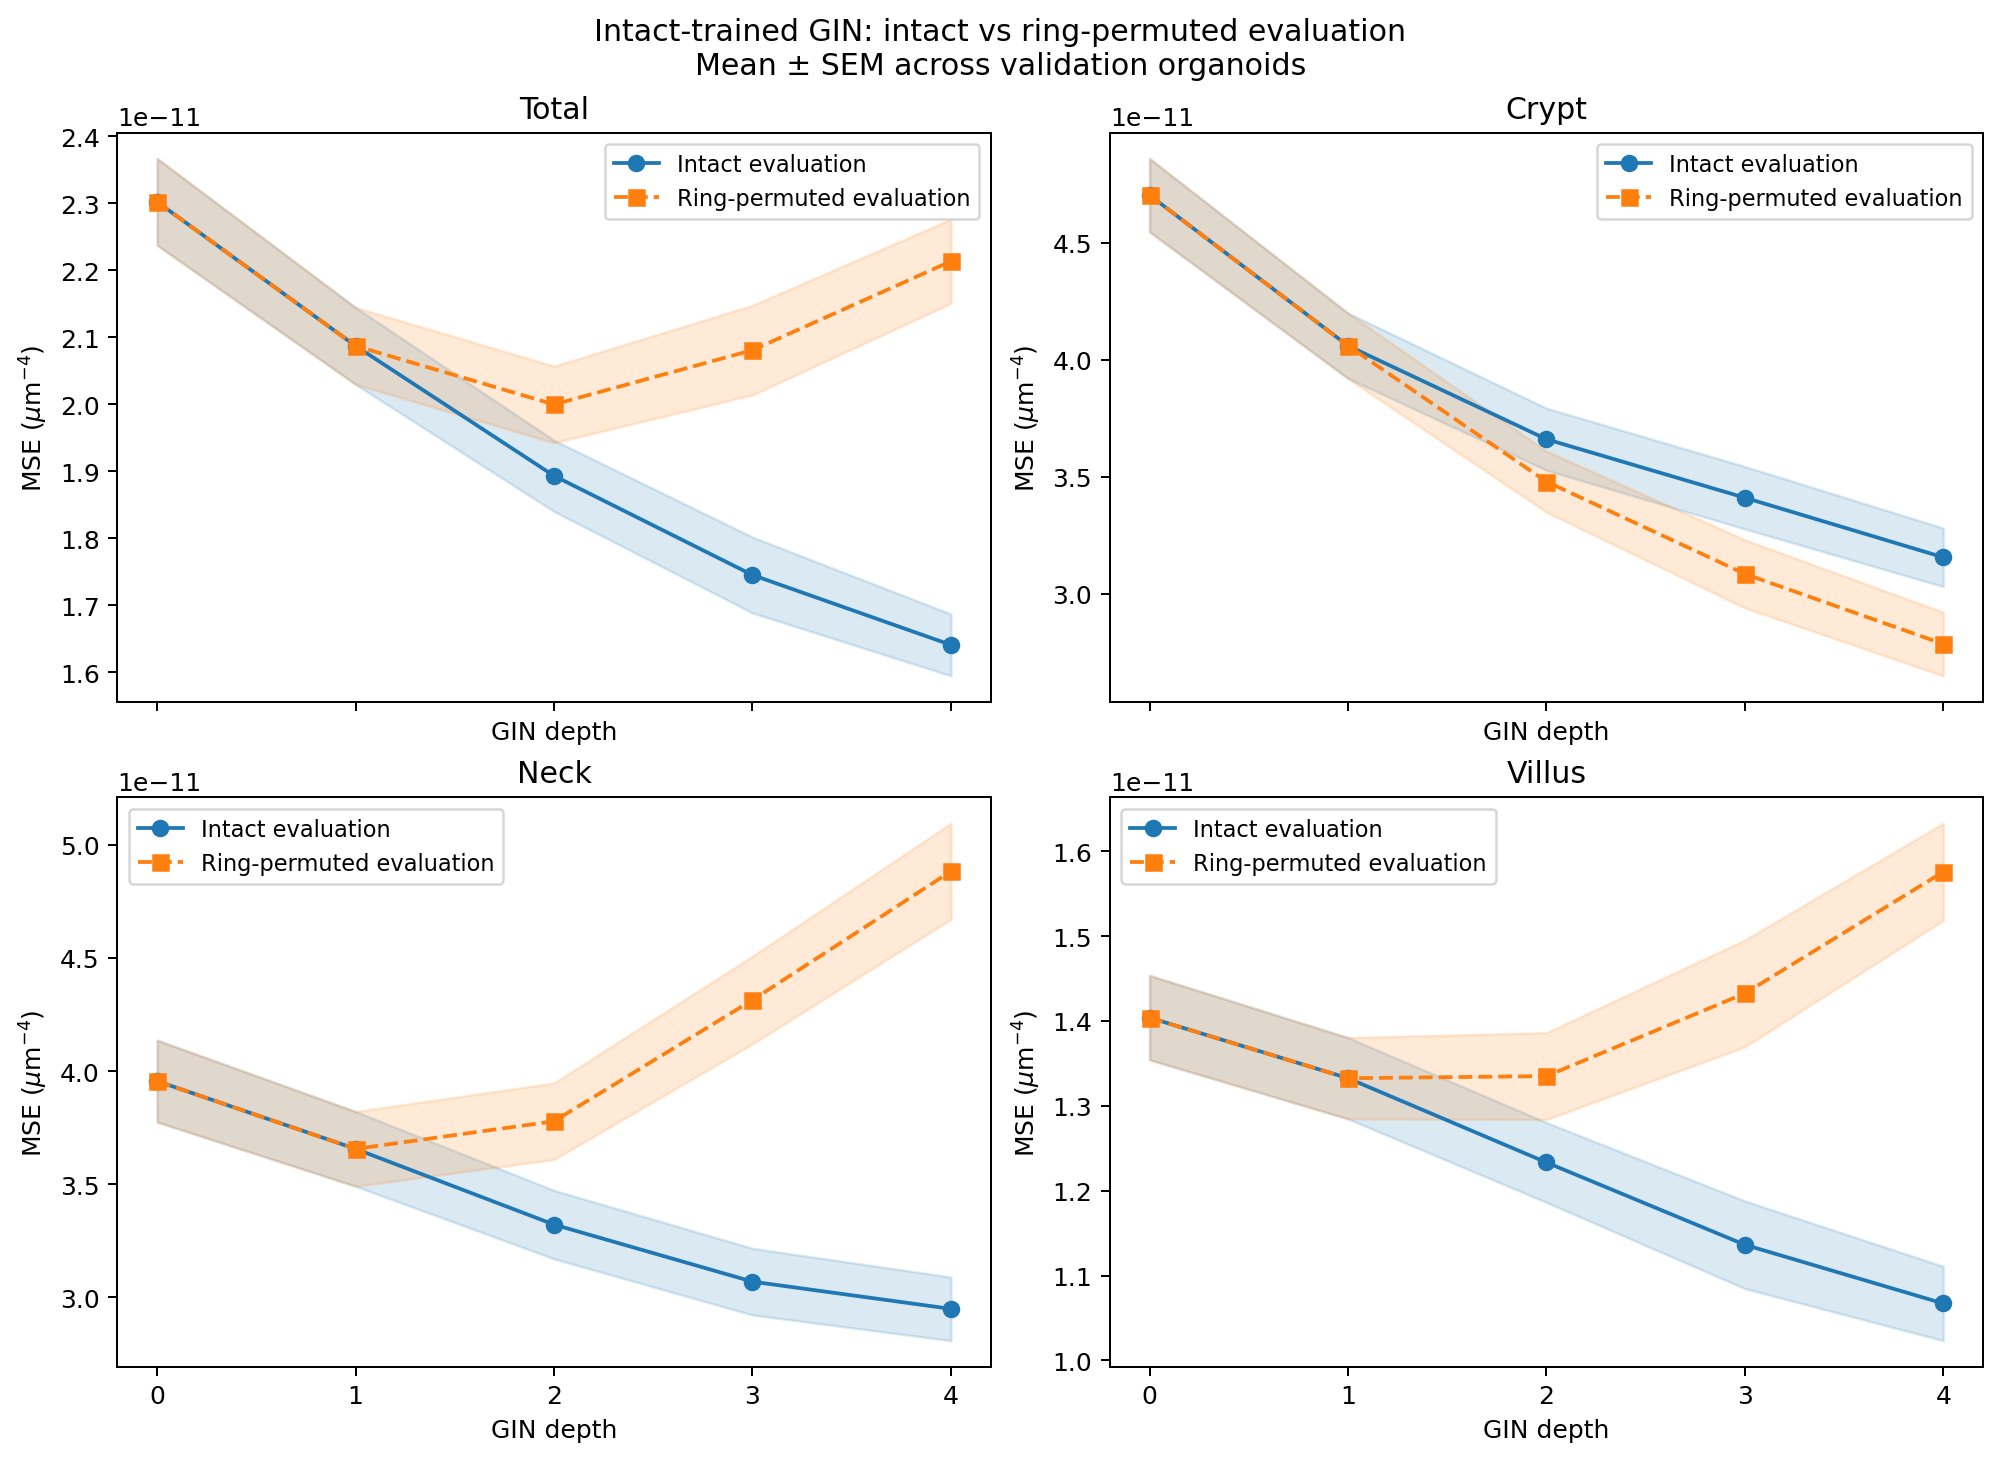

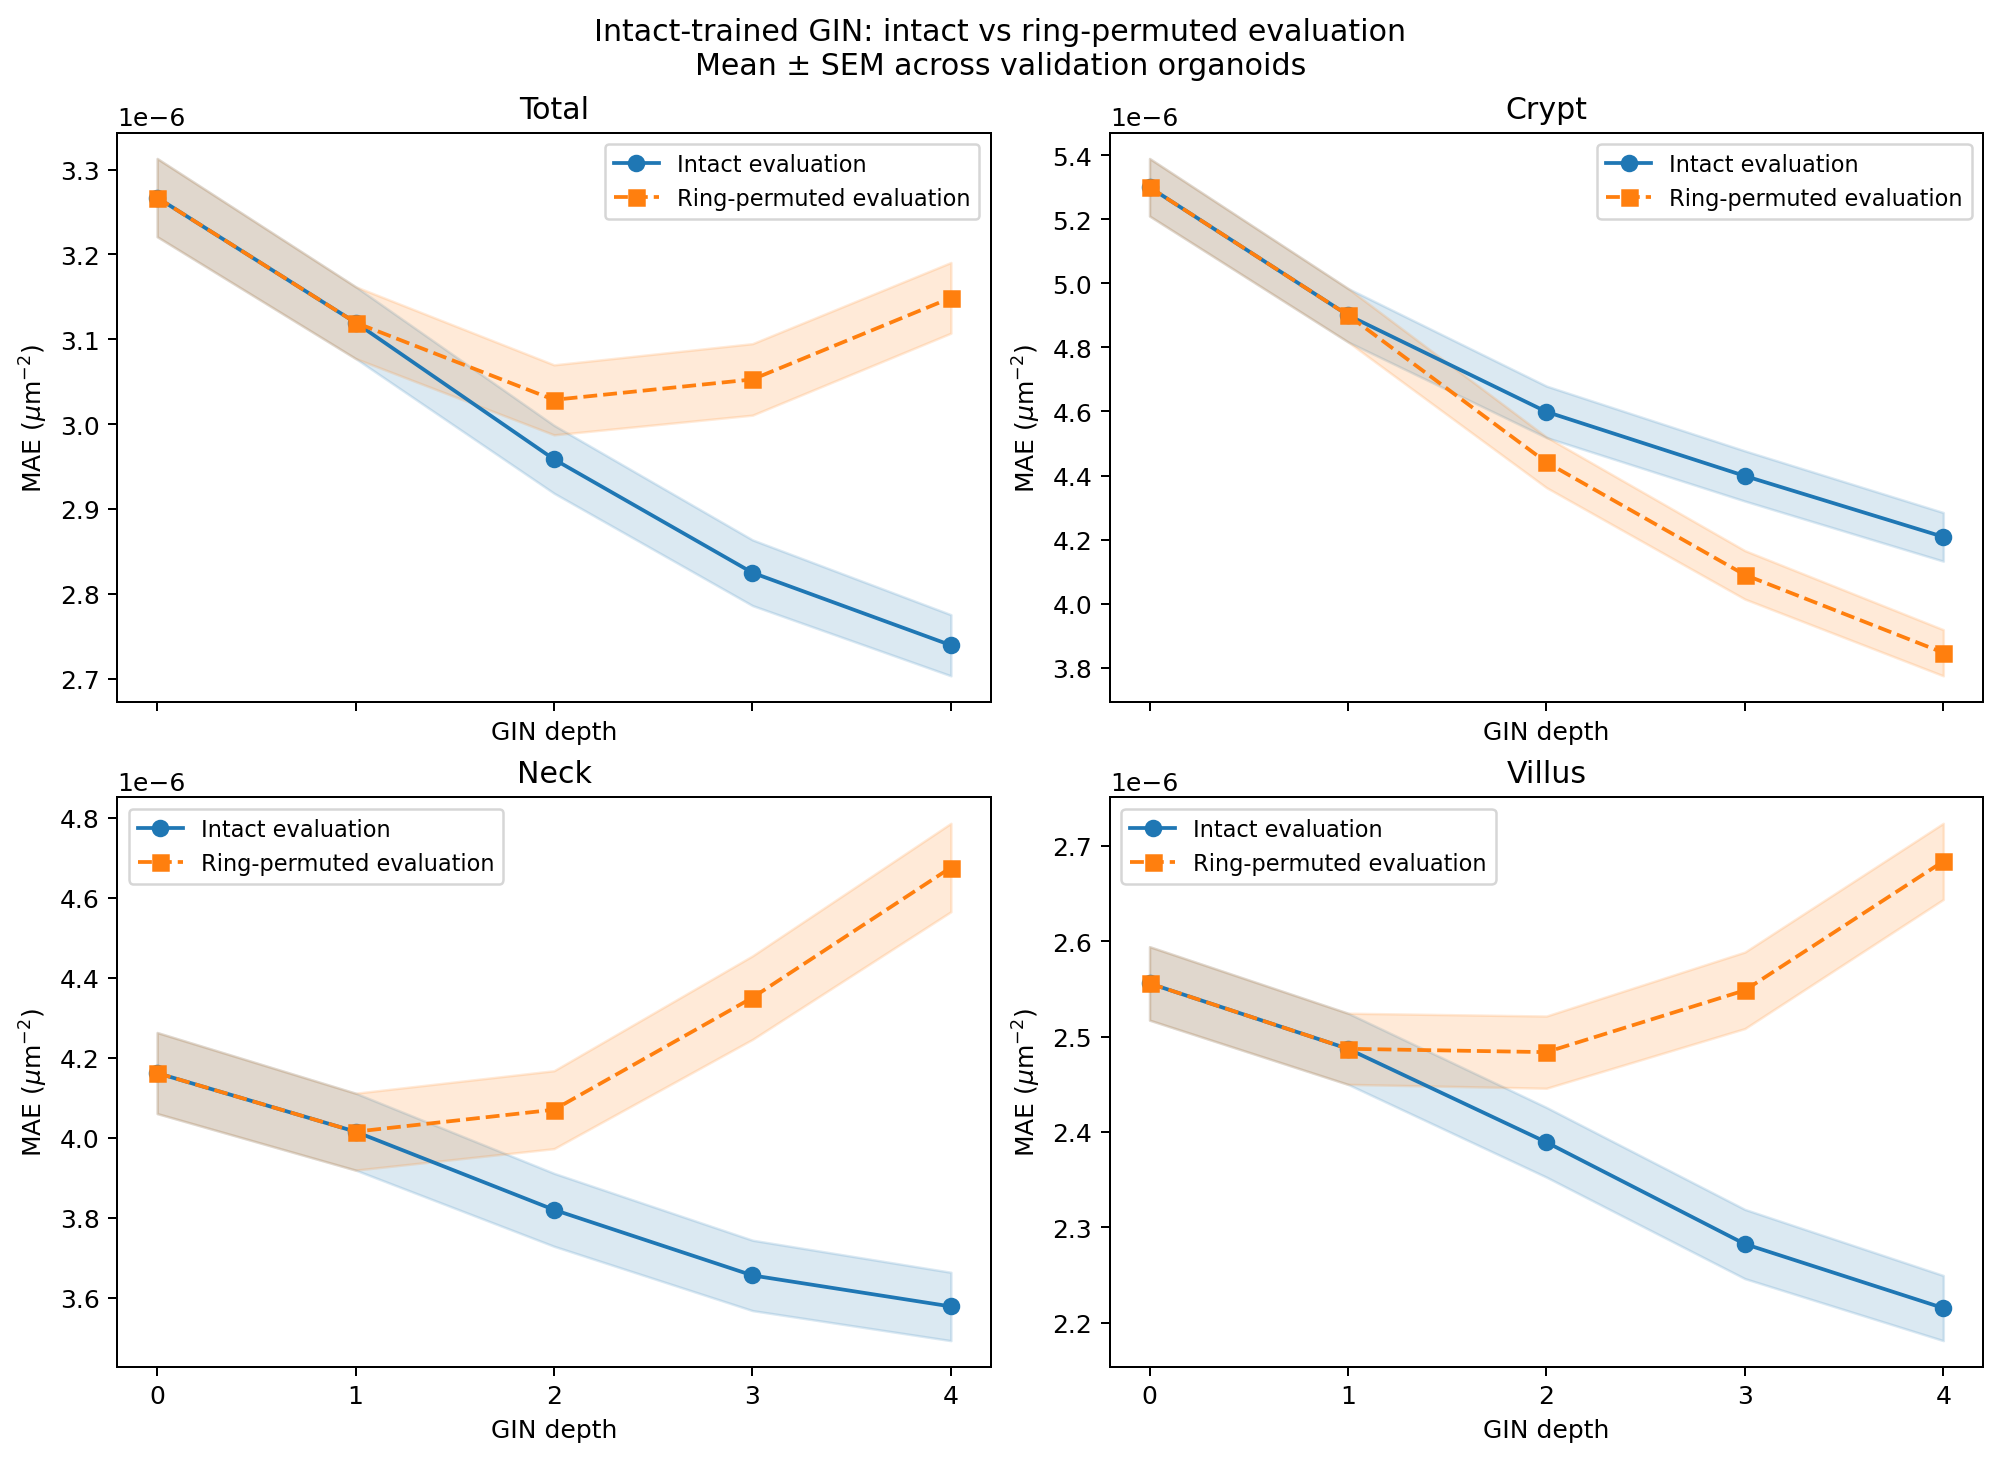

In [7]:
# Plot only intact-trained GINs, comparing the two evaluation signals in each region.
ring_comparison = permutations[permutations.condition.isin(['intact', 'ring_permuted'])].copy()
for metric in ['mse', 'mae']:
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, layout='constrained')
    for ax, region in zip(axes.flat, ['total', 'crypt', 'neck', 'villus']):
        for condition, label, color, style in [
            ('intact', 'Intact evaluation', 'tab:blue', 'o-'),
            ('ring_permuted', 'Ring-permuted evaluation', 'tab:orange', 's--'),
        ]:
            rows = ring_comparison[(ring_comparison.region == region) & (ring_comparison.condition == condition)]
            curve = organoid_mse_summary(rows, 'depth', value=metric).sort_values('depth')
            ax.plot(curve.depth, curve['mean'], style, color=color, label=label)
            ax.fill_between(curve.depth, curve['mean'] - curve['sem'], curve['mean'] + curve['sem'],
                            color=color, alpha=.16)
        ax.set(title=region.capitalize(), xlabel='GIN depth', ylabel=METRIC_LABELS[metric], xticks=range(5))
        ax.legend(fontsize=9)
    fig.suptitle('Intact-trained GIN: intact vs ring-permuted evaluation\nMean ± SEM across validation organoids')
    save_figure(fig, OUTPUT_DIR/f'inference_permutations_{metric}')
